# flow2 Phase 6Q：五目标体推理因果审计

**日期：2026-08-04｜正式训练：未开始｜案例：3 个钻遇 + 2 个未钻 label-9 立方体**

本 Notebook 只读取冻结运行产物，展示 Q0–Q3b 的机器结果和三维体；不会
重新优化、不会加载 flow U-Net、不会训练、不会覆盖任何实验目录。

**核心结论：** gravity 已出现“高 hard 物理拟合、错误三维”的非唯一性；
seismic 尚未充分接近观测，首先受自由体素参数化、非局部算子优化、
soft→hard 桥接和多类别物性替代共同限制，不能主要归因于非唯一性。

## 1. 权威资产与运行边界

In [1]:
from pathlib import Path
import json, sys, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager, colors as mcolors
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
font_path = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if font_path.is_file():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

def locate_project():
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        for candidate in (base, base / "project/geodata-3d-conditional"):
            if (candidate / "docs/PHASE6Q_SIMPLE_CAUSAL_SPEC.md").is_file():
                return candidate.resolve()
    raise FileNotFoundError("无法定位 geodata-3d-conditional 项目")

PROJECT = locate_project()
REPO = PROJECT.parents[1]
RUNS = PROJECT / "experiments/stage6_inference_causality/runs/five_body_cuboid_v1"
RUN = {
    "Q0Q1": RUNS / "q0_q1_full_v2",
    "Q2": RUNS / "q2_full_v2",
    "Q2b": RUNS / "q2b_full_v1",
    "Q2c": RUNS / "q2c_seismic_fine_v1",
    "Q3": RUNS / "q3_full_v2",
    "Q3b": RUNS / "q3b_binary_full_v1",
}

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))
def load_tensor(path):
    return torch.load(path, map_location="cpu", weights_only=True)
def load_array(path):
    value = load_tensor(path)
    return np.squeeze(value.detach().cpu().numpy())

summaries = {name: load_json(path / "summary.json") for name, path in RUN.items()}
required = [
    PROJECT / "docs/PHASE6Q_CAUSALITY_REPORT.md",
    RUN["Q0Q1"] / "tensors/truth_labels.pt",
    RUN["Q3"] / "optimization/seismic/correct/ste_embedding_rock/best_labels.pt",
]
missing = [str(path) for path in required if not path.is_file()]
if missing: raise FileNotFoundError("缺少权威资产:\n" + "\n".join(missing))
print("PROJECT =", PROJECT)
for name, summary in summaries.items():
    print(f"{name:4s}: {summary['status']}, {summary['stage']}, training={summary['formal_training_performed']}")
print("Q3 flow U-Net loaded =", summaries["Q3"]["flow_unet_loaded"])

PROJECT = /home/xmj/mcy/flowtrain_stochastic_interpolation-main/project/geodata-3d-conditional
Q0Q1: completed, phase6q_q0_q1_simple_causality, training=False
Q2  : completed, phase6q_q2_free_voxel, training=False
Q2b : completed, phase6q_q2b_hard_coordinate, training=False
Q2c : completed, phase6q_q2b_hard_coordinate, training=False
Q3  : completed, phase6q_q3_checkpoint_embedding_endpoint, training=False
Q3b : completed, phase6q_q3_checkpoint_embedding_endpoint, training=False
Q3 flow U-Net loaded = False


## 2. 问题被拆成哪些层？

- Q0：hard 候选穷举，检验观测/正演是否正确配对；
- Q1：已知十二候选和“恰有两个”的强结构先验；
- Q2：161,920 个自由二分类体素，不给位置、形状、数量或体积；
- Q2b/Q2c：只接受 hard physics 改善的离散坐标更新；
- Q3：真实 15 类 checkpoint embedding endpoint，不加载 flow；
- Q3b：查看 Q3 后冻结的二类别控制，隔离全类别物性竞争。

所有 optimizer 都只按 hard physics 选 best；hidden IoU/recall 仅为事后审计。

In [2]:
q0_rows = []
for mode, result in summaries["Q0Q1"]["enumeration"].items():
    q0_rows.append({
        "观测": mode,
        "truth rank": result["truth_pair_rank"],
        "truth RMSE": result["truth_pair_rmse"],
        "数值零候选数": result["near_numerical_zero_count"],
        "非真值第二名 RMSE": result["second_best_nontruth_rmse"],
        "baseline RMSE": result["baseline_rmse"],
    })
q0_table = pd.DataFrame(q0_rows)
display(q0_table.style.format({"truth RMSE":"{:.2e}", "非真值第二名 RMSE":"{:.8f}", "baseline RMSE":"{:.8f}"}))
print("Q0 结论：五种观测中，truth pair [4,6] 都是66个 hard 二体组合里的唯一数值零。")

,观测,truth rank,truth RMSE,数值零候选数,非真值第二名 RMSE,baseline RMSE
0,blurred_property,1,0.00e+00,1,0.05054074,0.05058185
1,gravity,1,0.00e+00,1,0.08934622,0.40612191
2,property,1,0.00e+00,1,0.06987713,0.06987713
3,reflectivity_spikes,1,0.00e+00,1,0.00709768,0.00709769
4,seismic,1,0.00e+00,1,0.00888581,0.00888582


Q0 结论：五种观测中，truth pair [4,6] 都是66个 hard 二体组合里的唯一数值零。


Q0 排除了真值观测错配、label→物性映射错位或 hard forward 无法再现真值这一类总体程序错误。它不代表自由体素反演一定容易。

## 3. correct seismic：逐层去掉先验后的结果

In [3]:
def opt(summary, mode, control, method):
    return next(row for row in summary["optimization"]
                if row["mode"] == mode and row["control"] == control and row.get("method") == method)
def hard_row(stage, parameterization, row, metric_key="best_metrics"):
    m = row[metric_key]
    return {
        "层级": stage, "参数化/方法": parameterization,
        "hard attainment": m["hard_attainment"],
        "hidden IoU": m.get("hidden_iou", m.get("body_recall", np.nan)),
        "precision": m.get("hidden_precision", m.get("body_precision", np.nan)),
        "recall": m.get("hidden_recall", m.get("body_recall", np.nan)),
        "body0 recall": m.get("hidden_body_0_recall", m.get("body_recall", np.nan)),
        "body1 recall": m.get("hidden_body_1_recall", m.get("body_recall", np.nan)),
        "best/final step": row.get("best_step", row.get("iterations_completed", np.nan)),
    }

rows = []
q1 = summaries["Q0Q1"]
rows += [hard_row("Q1", "candidate soft", opt(q1,"seismic","correct","soft")),
         hard_row("Q1", "candidate STE top-2", opt(q1,"seismic","correct","ste_top2"))]
q2 = summaries["Q2"]
rows += [hard_row("Q2", "free voxel soft", opt(q2,"seismic","correct","soft_voxel")),
         hard_row("Q2", "free voxel STE", opt(q2,"seismic","correct","ste_voxel"))]
q2b = next(r for r in summaries["Q2b"]["optimization"] if r["mode"]=="seismic" and r["control"]=="correct")
q2c = next(r for r in summaries["Q2c"]["optimization"] if r["mode"]=="seismic" and r["control"]=="correct")
rows += [hard_row("Q2b", "hard flips 32–512", q2b, "final_metrics"),
         hard_row("Q2c", "hard flips 1–32", q2c, "final_metrics")]
q3 = summaries["Q3"]
rows += [hard_row("Q3", "15-class soft embedding", opt(q3,"seismic","correct","soft_embedding")),
         hard_row("Q3", "14-rock STE", opt(q3,"seismic","correct","ste_embedding_rock"))]
q3b = summaries["Q3b"]
rows += [hard_row("Q3b", "binary soft embedding", opt(q3b,"seismic","correct","soft_embedding_binary")),
         hard_row("Q3b", "binary STE", opt(q3b,"seismic","correct","ste_embedding_binary"))]
seismic_ladder = pd.DataFrame(rows)
display(seismic_ladder.style.format({
    "hard attainment":"{:.2%}", "hidden IoU":"{:.2%}", "precision":"{:.2%}",
    "recall":"{:.2%}", "body0 recall":"{:.2%}", "body1 recall":"{:.2%}",
}))

,层级,参数化/方法,hard attainment,hidden IoU,precision,recall,body0 recall,body1 recall,best/final step
0,Q1,candidate soft,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,nan
1,Q1,candidate STE top-2,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,nan
2,Q2,free voxel soft,3.30%,10.00%,100.00%,10.00%,10.00%,10.00%,110.000000
3,Q2,free voxel STE,10.26%,40.00%,100.00%,40.00%,40.00%,40.00%,40.000000
4,Q2b,hard flips 32–512,15.64%,70.00%,100.00%,70.00%,70.00%,70.00%,4.000000
5,Q2c,hard flips 1–32,4.00%,12.50%,100.00%,12.50%,15.00%,10.00%,6.000000
6,Q3,15-class soft embedding,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.000000
7,Q3,14-rock STE,37.80%,20.00%,100.00%,20.00%,20.00%,20.00%,200.000000
8,Q3b,binary soft embedding,3.30%,10.00%,100.00%,10.00%,10.00%,10.00%,110.000000
9,Q3b,binary STE,10.26%,40.00%,100.00%,40.00%,40.00%,40.00%,30.000000


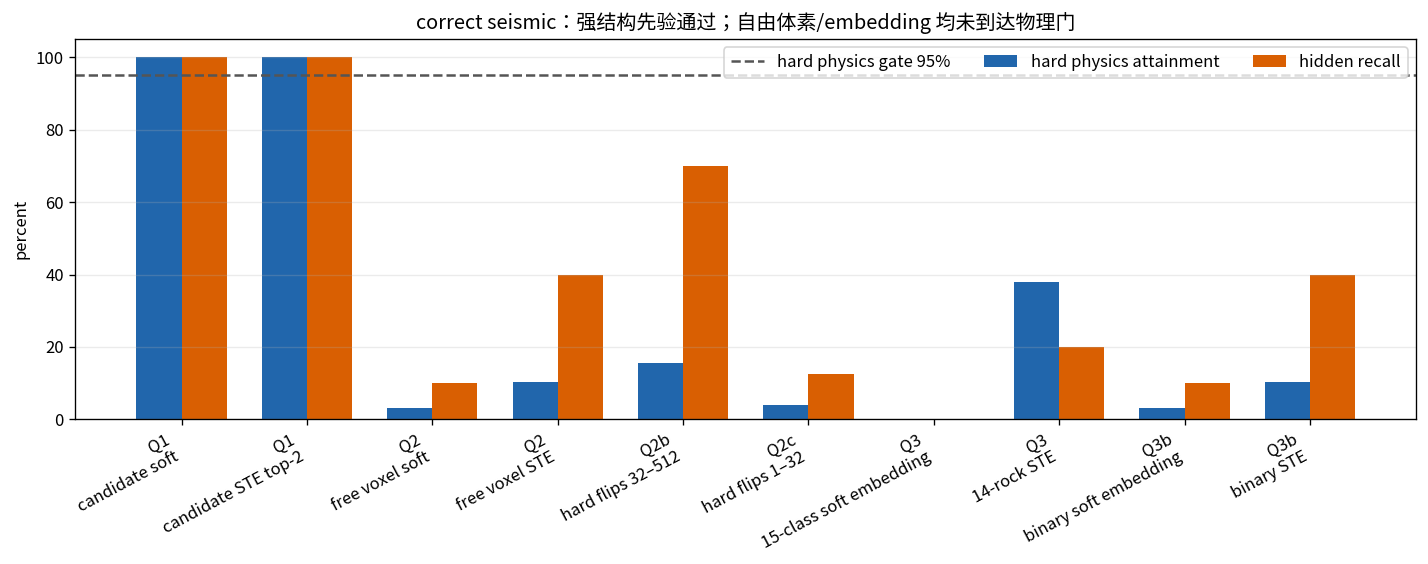

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.8))
labels = seismic_ladder["层级"] + "\n" + seismic_ladder["参数化/方法"]
x = np.arange(len(labels))
ax.bar(x - 0.18, 100*seismic_ladder["hard attainment"], width=0.36, label="hard physics attainment", color="#2166ac")
ax.bar(x + 0.18, 100*seismic_ladder["recall"], width=0.36, label="hidden recall", color="#d95f02")
ax.axhline(95, color="#555555", linestyle="--", label="hard physics gate 95%")
ax.set_xticks(x, labels, rotation=28, ha="right")
ax.set_ylabel("percent")
ax.set_title("correct seismic：强结构先验通过；自由体素/embedding 均未到达物理门")
ax.legend(ncol=3); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.show()

Q1 的成功说明观测中存在恢复信号，但它使用了候选位置和“恰有两个”的强先验。
去掉这些先验后，hard-only Q2b 虽恢复两个岩体各70%，地震 RMSE 只消除15.64%；
它不是“地球物理已经正确、三维仍错”的非唯一解。Q2c 表明更细的单点/小块
更新不能解决耦合界面所需的协调移动。

## 4. 三维真值、基线与 correct seismic 恢复

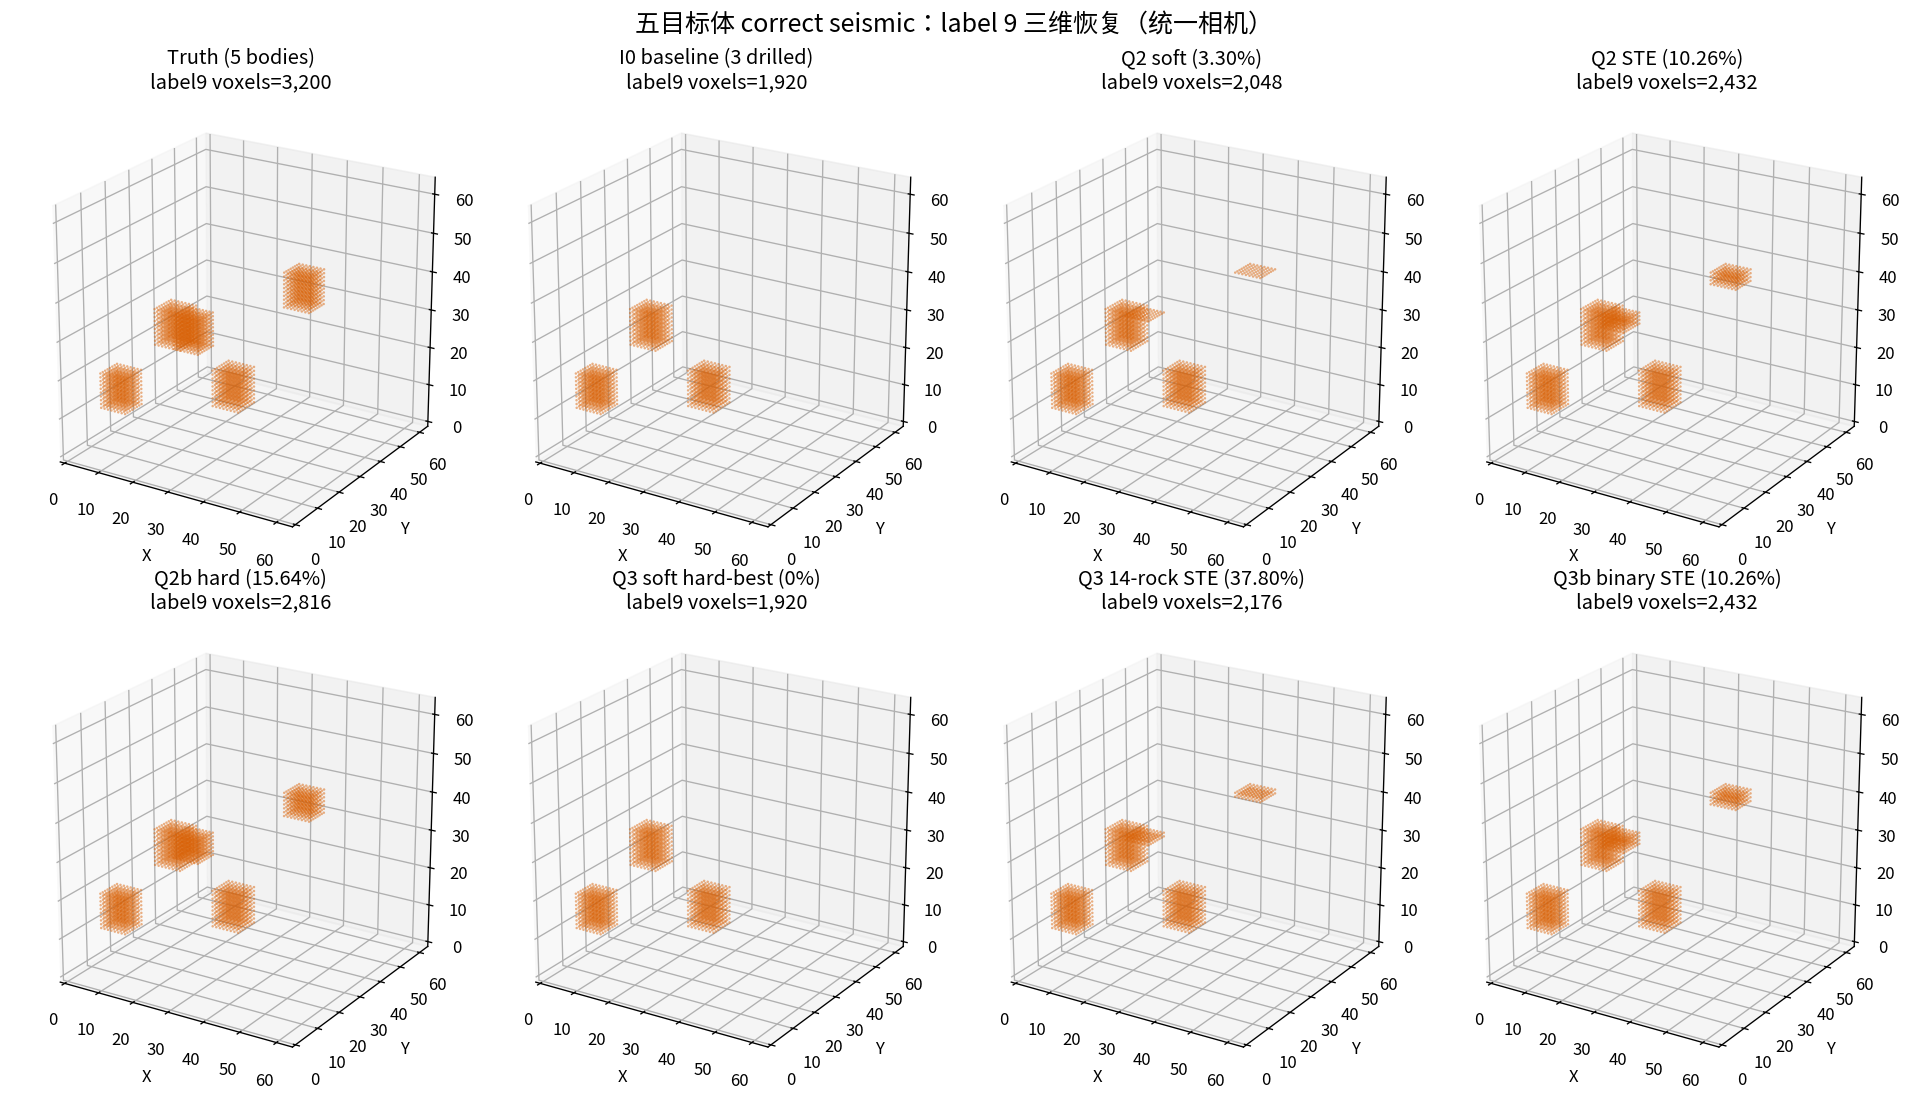

In [5]:
TENSORS = RUN["Q0Q1"] / "tensors"
truth_labels = load_tensor(TENSORS / "truth_labels.pt").long()
baseline_labels = load_tensor(TENSORS / "baseline_labels.pt").long()
fixed_mask = load_tensor(TENSORS / "fixed_target_mask.pt").bool()
condition_mask = load_tensor(TENSORS / "condition_mask.pt").bool()

def occ(path): return load_tensor(path).float().squeeze().numpy() > .5
def labels(path): return load_tensor(path).long().squeeze().numpy()
truth_target = truth_labels.squeeze().numpy() == 9
baseline_target = baseline_labels.squeeze().numpy() == 9
target_volumes = {
    "Truth (5 bodies)": truth_target,
    "I0 baseline (3 drilled)": baseline_target,
    "Q2 soft (3.30%)": occ(RUN["Q2"] / "optimization/seismic/correct/soft_voxel/best_hard_occupancy.pt"),
    "Q2 STE (10.26%)": occ(RUN["Q2"] / "optimization/seismic/correct/ste_voxel/best_hard_occupancy.pt"),
    "Q2b hard (15.64%)": occ(RUN["Q2b"] / "optimization/seismic/correct/hard_coordinate/final_hard_occupancy.pt"),
    "Q3 soft hard-best (0%)": labels(RUN["Q3"] / "optimization/seismic/correct/soft_embedding/best_labels.pt") == 9,
    "Q3 14-rock STE (37.80%)": labels(RUN["Q3"] / "optimization/seismic/correct/ste_embedding_rock/best_labels.pt") == 9,
    "Q3b binary STE (10.26%)": labels(RUN["Q3b"] / "optimization/seismic/correct/ste_embedding_binary/best_labels.pt") == 9,
}

def scatter_binary(ax, mask, title):
    points = np.argwhere(mask)
    if len(points): ax.scatter(*points.T, s=2.2, alpha=.48, c="#d95f02", linewidths=0, rasterized=True)
    ax.set_title(f"{title}\nlabel9 voxels={int(mask.sum()):,}")
    ax.set(xlim=(0,63), ylim=(0,63), zlim=(0,63), xlabel="X", ylabel="Y", zlabel="Z")
    ax.set_box_aspect((1,1,1)); ax.view_init(elev=22, azim=-58)

fig = plt.figure(figsize=(16, 9.5))
for i, (title, mask) in enumerate(target_volumes.items(), 1):
    scatter_binary(fig.add_subplot(2,4,i,projection="3d"), mask, title)
fig.suptitle("五目标体 correct seismic：label 9 三维恢复（统一相机）", fontsize=15, y=.98)
plt.tight_layout(); plt.show()

Q3 的 37.80% 物理改善并不等于 label-9 恢复更完整：它只恢复两个岩体各20%，并利用了多种其他岩性。

## 5. soft→hard 分叉与观测控制

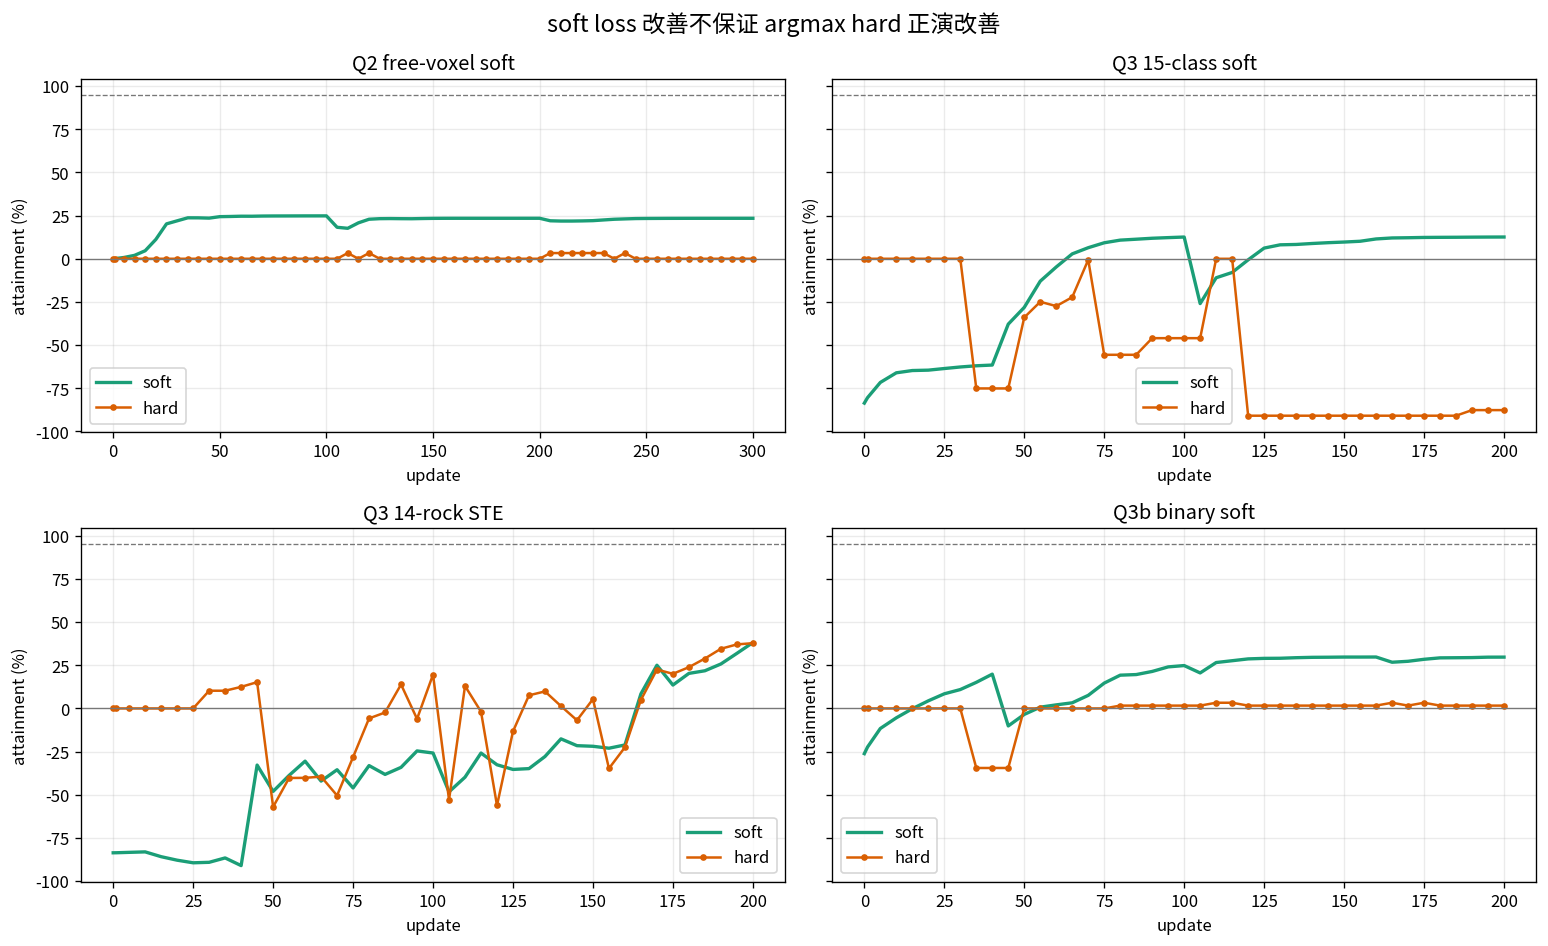

,层级,control,method,hard attainment,IoU,hidden recall
0,Q2,correct,soft_voxel,3.30%,10.00%,10.00%
1,Q2,correct,ste_voxel,10.26%,40.00%,40.00%
2,Q2,zero,soft_voxel,0.00%,0.00%,0.00%
3,Q2,zero,ste_voxel,0.00%,0.00%,0.00%
4,Q2,shuffled_xy,soft_voxel,1.50%,0.13%,0.16%
5,Q2,shuffled_xy,ste_voxel,4.58%,0.36%,0.62%
6,Q3,correct,soft_embedding,0.00%,0.00%,0.00%
7,Q3,correct,ste_embedding_rock,37.80%,20.00%,20.00%
8,Q3,zero,soft_embedding,0.00%,0.00%,0.00%
9,Q3,zero,ste_embedding_rock,0.00%,0.00%,0.00%


In [6]:
trace_specs = {
    "Q2 free-voxel soft": RUN["Q2"] / "optimization/seismic/correct/soft_voxel/trace.csv",
    "Q3 15-class soft": RUN["Q3"] / "optimization/seismic/correct/soft_embedding/trace.csv",
    "Q3 14-rock STE": RUN["Q3"] / "optimization/seismic/correct/ste_embedding_rock/trace.csv",
    "Q3b binary soft": RUN["Q3b"] / "optimization/seismic/correct/soft_embedding_binary/trace.csv",
}
fig, axes = plt.subplots(2,2,figsize=(13,8),sharex=False,sharey=True)
for ax, (title,path) in zip(axes.ravel(),trace_specs.items()):
    df=pd.read_csv(path)
    ax.plot(df.step,100*df.soft_attainment,label="soft",color="#1b9e77",lw=2)
    ax.plot(df.step,100*df.hard_attainment,"o-",label="hard",color="#d95f02",ms=3)
    ax.axhline(0,color="#777",lw=.8); ax.axhline(95,color="#777",ls="--",lw=.8)
    ax.set_title(title); ax.set_xlabel("update"); ax.set_ylabel("attainment (%)")
    ax.grid(alpha=.25); ax.legend()
fig.suptitle("soft loss 改善不保证 argmax hard 正演改善",fontsize=14)
plt.tight_layout(); plt.show()

control_rows=[]
for stage, summary, methods in [
    ("Q2", summaries["Q2"], ["soft_voxel","ste_voxel"]),
    ("Q3", summaries["Q3"], ["soft_embedding","ste_embedding_rock"]),
    ("Q3b", summaries["Q3b"], ["soft_embedding_binary","ste_embedding_binary"]),
]:
    for control in ["correct","zero","shuffled_xy"]:
        for method in methods:
            row=opt(summary,"seismic",control,method); m=row["best_metrics"]
            control_rows.append({"层级":stage,"control":control,"method":method,
                                 "hard attainment":m["hard_attainment"],"IoU":m["hidden_iou"],
                                 "hidden recall":m["hidden_recall"]})
display(pd.DataFrame(control_rows).style.format({"hard attainment":"{:.2%}","IoU":"{:.2%}","hidden recall":"{:.2%}"}))

Q3 普通 soft embedding 的最终 soft/hard seismic attainment 分别为12.59%和
−87.64%，hard-only best 仍是 I0。rock-STE 的 correct 结果明显优于 zero/
shuffled，证明梯度不是纯噪声；但37.80%仍远低于95%门。

## 6. hard seismic 剖面：仍未接近 observed

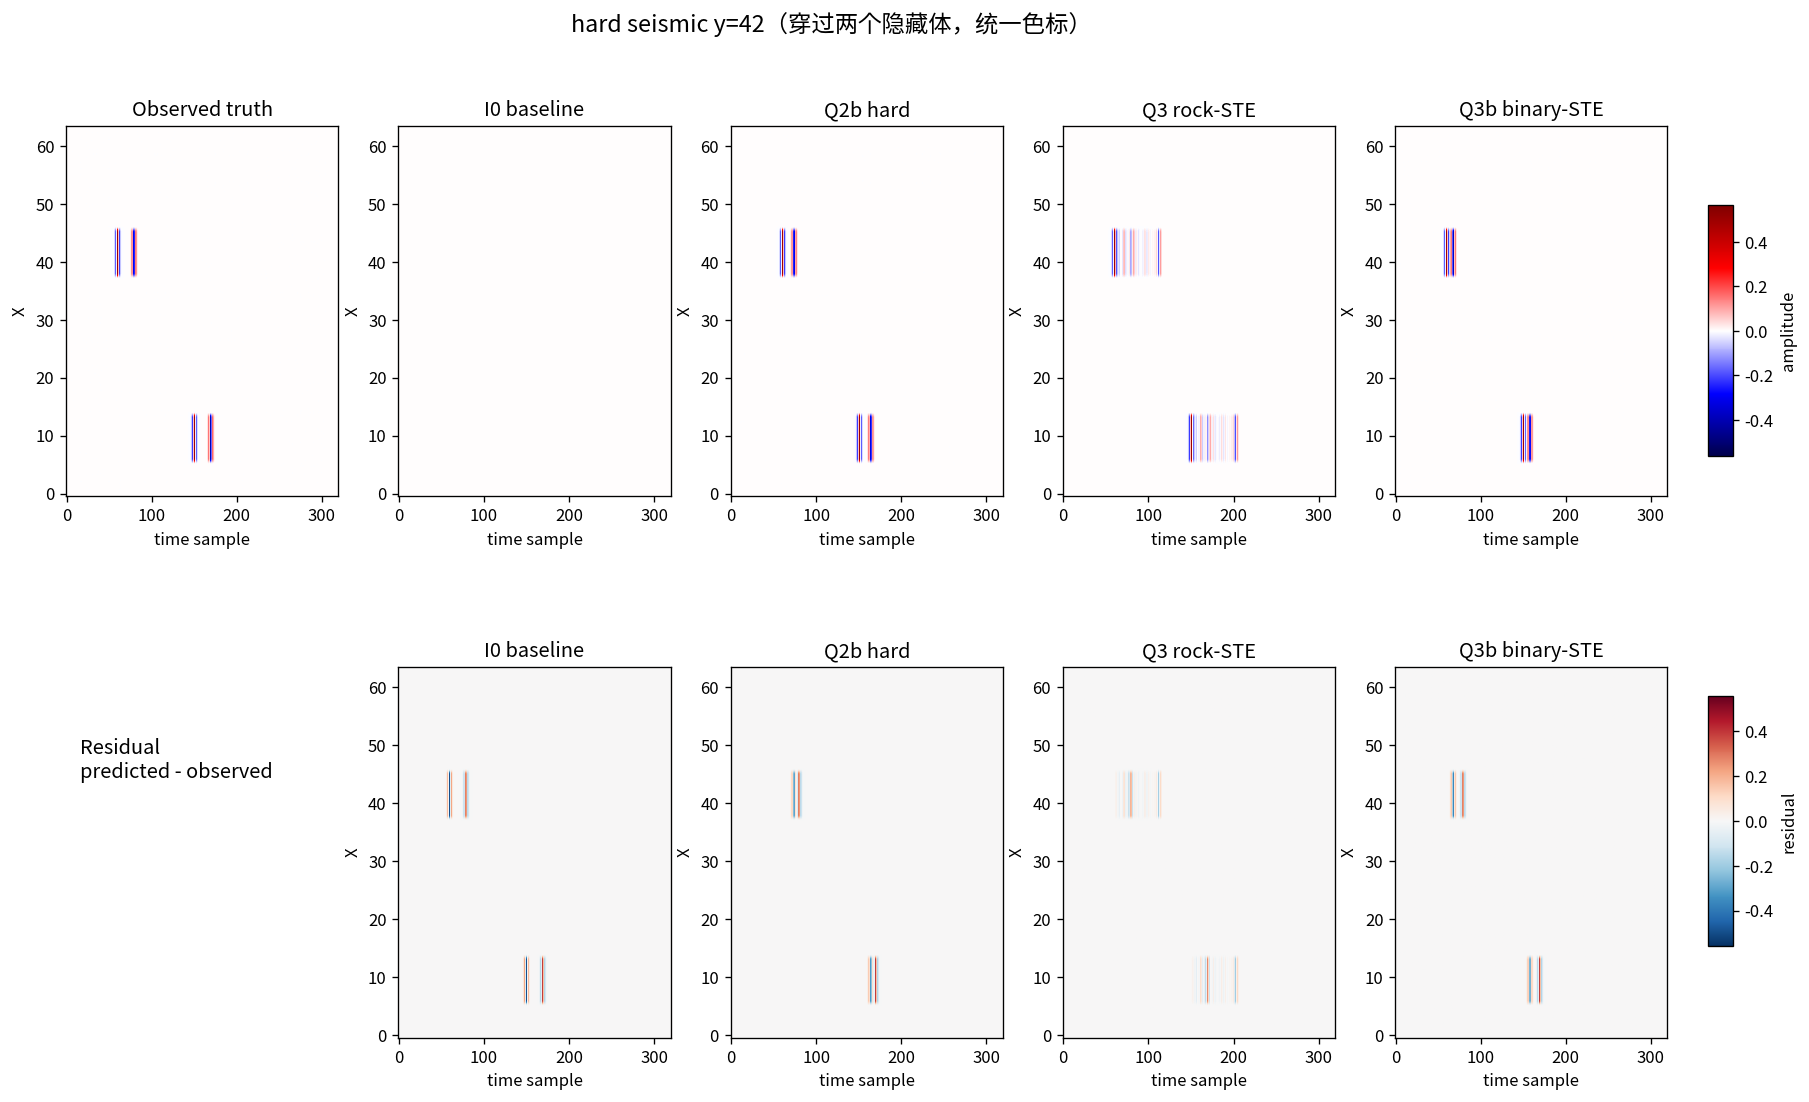

In [7]:
if str(PROJECT) not in sys.path: sys.path.insert(0,str(PROJECT))
from guidance.gravity import density_table_from_config, gravity_operator_from_config
from guidance.seismic import acoustic_tables_from_config, seismic_operator_from_config
from guidance.simple_causality import AnalyticObservationSuite, build_simple_causal_case

cfg=load_json(PROJECT/"experiments/stage6_inference_causality/configs/five_body_cuboid_v1.json")
case=build_simple_causal_case(cfg)
acoustic,_=acoustic_tables_from_config(load_json(REPO/cfg["acoustic_config"]),15)
density,_=density_table_from_config(load_json(REPO/cfg["density_config"]),15)
seismic_op,_=seismic_operator_from_config(load_json(REPO/cfg["seismic_config"]),grid_shape=cfg["grid_shape"])
gravity_op,_=gravity_operator_from_config(load_json(REPO/cfg["gravity_config"]),grid_shape=cfg["grid_shape"])
suite=AnalyticObservationSuite(case,acoustic_property_table=acoustic.property_table,density_table=density,
                                seismic_operator=seismic_op,gravity_operator=gravity_op,blur_sigma_voxels=cfg["blur_sigma_voxels"])

def labels_from_occ(path):
    occupancy=load_tensor(path)>0.5
    result=baseline_labels.clone()
    result[(case.subsurface_mask)&~occupancy]=0
    result[occupancy]=9
    return result
seismic_models={
    "Observed truth":truth_labels,
    "I0 baseline":baseline_labels,
    "Q2b hard":labels_from_occ(RUN["Q2b"] / "optimization/seismic/correct/hard_coordinate/final_hard_occupancy.pt"),
    "Q3 rock-STE":load_tensor(RUN["Q3"] / "optimization/seismic/correct/ste_embedding_rock/best_labels.pt").long(),
    "Q3b binary-STE":load_tensor(RUN["Q3b"] / "optimization/seismic/correct/ste_embedding_binary/best_labels.pt").long(),
}
fields={name:suite.field_from_labels(value,"seismic").squeeze().detach().numpy() for name,value in seismic_models.items()}
observed=fields["Observed truth"]
y_index=42
sections={name:value[:,y_index,:] for name,value in fields.items()}
limit=max(np.abs(v).max() for v in sections.values())
residuals={name:value-sections["Observed truth"] for name,value in sections.items() if name!="Observed truth"}
rlimit=max(np.abs(v).max() for v in residuals.values())
fig,axes=plt.subplots(2,5,figsize=(17,9.5))
for ax,(title,data) in zip(axes[0],sections.items()):
    im=ax.imshow(data,aspect="auto",origin="lower",cmap="seismic",vmin=-limit,vmax=limit)
    ax.set_title(title); ax.set_xlabel("time sample"); ax.set_ylabel("X")
axes[1,0].axis("off"); axes[1,0].text(.05,.7,"Residual\npredicted - observed",fontsize=12)
for ax,(title,data) in zip(axes[1,1:],residuals.items()):
    im2=ax.imshow(data,aspect="auto",origin="lower",cmap="RdBu_r",vmin=-rlimit,vmax=rlimit)
    ax.set_title(title); ax.set_xlabel("time sample"); ax.set_ylabel("X")
fig.suptitle(f"hard seismic y={y_index}（穿过两个隐藏体，统一色标）",fontsize=14)
fig.subplots_adjust(top=.88, bottom=.08, hspace=.46, wspace=.22, right=.91)
cax1=fig.add_axes([.93,.59,.012,.22]); fig.colorbar(im,cax=cax1,label="amplitude")
cax2=fig.add_axes([.93,.16,.012,.22]); fig.colorbar(im2,cax=cax2,label="residual")
plt.show()

## 7. gravity：高物理拟合但错误三维，才是非唯一性

,层级,方法,hard attainment,hidden IoU,precision,recall
0,Q2,soft_voxel,93.85%,9.53%,17.78%,17.03%
1,Q2,ste_voxel,73.78%,6.54%,14.11%,10.86%
2,Q2b,hard coordinate,85.78%,0.00%,0.00%,0.00%
3,Q3,soft_embedding,0.00%,0.00%,0.00%,0.00%
4,Q3,ste_embedding_rock,70.67%,0.00%,0.00%,0.00%
5,Q3b,soft_embedding_binary,0.00%,0.00%,0.00%,0.00%
6,Q3b,ste_embedding_binary,43.62%,0.00%,0.00%,0.00%


Q3 gravity rock-STE changed label counts = {6: 1304}


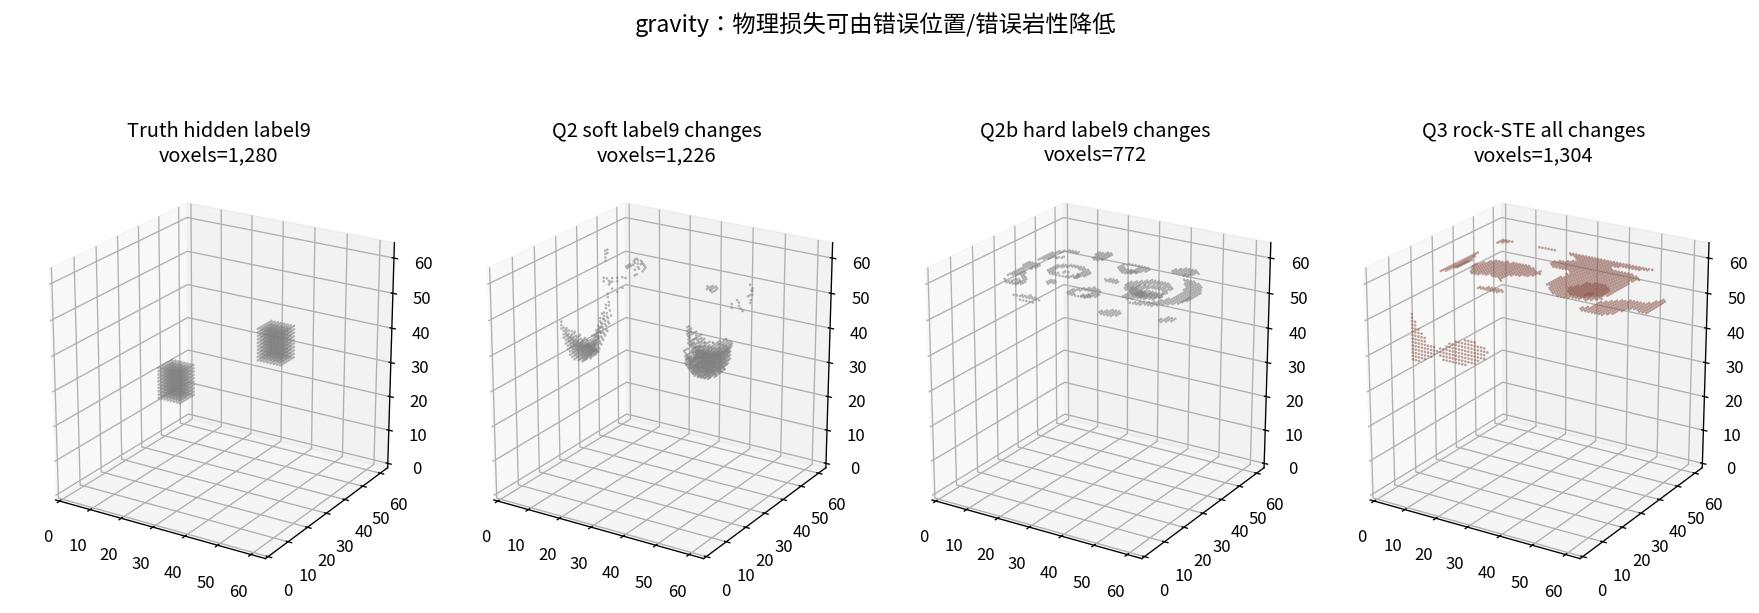

In [8]:
gravity_rows=[]
for stage,summary,method,metric_key in [
    ("Q2",summaries["Q2"],"soft_voxel","best_metrics"),
    ("Q2",summaries["Q2"],"ste_voxel","best_metrics"),
    ("Q3",summaries["Q3"],"soft_embedding","best_metrics"),
    ("Q3",summaries["Q3"],"ste_embedding_rock","best_metrics"),
    ("Q3b",summaries["Q3b"],"soft_embedding_binary","best_metrics"),
    ("Q3b",summaries["Q3b"],"ste_embedding_binary","best_metrics"),
]:
    row=opt(summary,"gravity","correct",method); m=row[metric_key]
    gravity_rows.append({"层级":stage,"方法":method,"hard attainment":m["hard_attainment"],
                         "hidden IoU":m["hidden_iou"],"precision":m["hidden_precision"],"recall":m["hidden_recall"]})
hardg=next(r for r in summaries["Q2b"]["optimization"] if r["mode"]=="gravity")
m=hardg["final_metrics"]
gravity_rows.insert(2,{"层级":"Q2b","方法":"hard coordinate","hard attainment":m["hard_attainment"],
                       "hidden IoU":m["hidden_iou"],"precision":m["hidden_precision"],"recall":m["hidden_recall"]})
display(pd.DataFrame(gravity_rows).style.format({"hard attainment":"{:.2%}","hidden IoU":"{:.2%}","precision":"{:.2%}","recall":"{:.2%}"}))

q3g=load_tensor(RUN["Q3"] / "optimization/gravity/correct/ste_embedding_rock/best_labels.pt").long().squeeze().numpy()
base_np=baseline_labels.squeeze().numpy()
changed=q3g!=base_np
vals,counts=np.unique(q3g[changed],return_counts=True)
print("Q3 gravity rock-STE changed label counts =",dict(zip(vals.tolist(),counts.tolist())))

gravity_masks={
    "Truth hidden label9":truth_target & ~baseline_target,
    "Q2 soft label9 changes":occ(RUN["Q2"] / "optimization/gravity/correct/soft_voxel/best_hard_occupancy.pt") & ~baseline_target,
    "Q2b hard label9 changes":occ(RUN["Q2b"] / "optimization/gravity/correct/hard_coordinate/final_hard_occupancy.pt") & ~baseline_target,
    "Q3 rock-STE all changes":changed,
}
fig=plt.figure(figsize=(15,5.3))
for i,(title,mask) in enumerate(gravity_masks.items(),1):
    ax=fig.add_subplot(1,4,i,projection="3d"); pts=np.argwhere(mask)
    color=q3g[mask] if title.startswith("Q3") else np.full(len(pts),9)
    if len(pts): ax.scatter(*pts.T,c=color,cmap="tab20",vmin=-1,vmax=13,s=2.5,alpha=.55,linewidths=0)
    ax.set_title(f"{title}\nvoxels={len(pts):,}"); ax.set(xlim=(0,63),ylim=(0,63),zlim=(0,63))
    ax.set_box_aspect((1,1,1)); ax.view_init(22,-58)
fig.suptitle("gravity：物理损失可由错误位置/错误岩性降低",fontsize=14,y=.98)
fig.subplots_adjust(top=.78, left=.02, right=.98, bottom=.03, wspace=.06)
plt.show()

Q2 soft gravity 消除了93.85%的 hard RMSE，但 hidden IoU 只有9.53%；Q2b
消除85.78%而 IoU=0；Q3 rock-STE 消除70.67%，1,304个变化体素全部变成
raw label 6。这里已经满足“地球物理接近、三维不同”，可以明确归为非唯一性/
物性替代。seismic 没有达到这一前提。

## 8. 对 Phase 1–4 与 mu 上限结论的修正

1. Phase 1/2 解决的是直接、全分辨率、可辨识属性通道的 soft-hard 映射；
   模糊和正演把它变成邻域/界面/acquisition-domain 约束后，问题会重新出现。
2. 本实验没有地质结构 loss 或“通过阈值”，physics-only 仍失败，因此不能解释为
   总 loss 被地质项提前降到阈值。
3. Q0/Q1 排除了总体正演程序错误；Q2–Q3 的失败来自参数化与优化链，而不是
   真值观测不可生成。
4. 原“mu/cap 上限影响小”只对原控制器和局部参数化成立。hard-forward 和类别
   约束把 correct seismic 从0–10%改到37.80%，说明不能外推为“任何更强物理
   干预都无效”。但单纯放大原 soft 梯度仍不会自动解决 hard 对齐。
5. 当前网络从未学习 acquisition-domain 地球物理残差对应的地质更新；Q3 尚未
   使用 flow，所以已证明训练前存在独立的 decoder/optimizer 缺口。后续 Q4
   才量化 flow 额外造成的冲突。

## 9. Phase 6B 实施计划与验收门

训练前先完成 Q4 冻结 flow 轨迹隔离，并把本简单体标注为解析机制体而非
StructuralGeo 分布内验证。之后 adapter 训练必须同时学习 all-class hard-aware
endpoint/velocity 对齐与 acquisition-domain physics，不能只优化 soft expected
property。

验收至少包括：held-out split/manifest 固定；correct 显著优于 zero/shuffled；
hard seismic attainment ≥95%；hidden/body 或 held-out 地质指标同时通过；条件
零违规；基模 hash 不变且无基模梯度；gravity 与 seismic 分开报告物理拟合和
地质恢复。soft loss 不能替代 hard physics 门。

**截至本 Notebook：上述训练尚未开始。**

In [9]:
artifacts=pd.DataFrame([
    {"内容":"冻结规范","路径":"docs/PHASE6Q_SIMPLE_CAUSAL_SPEC.md"},
    {"内容":"人工结论报告","路径":"docs/PHASE6Q_CAUSALITY_REPORT.md"},
    {"内容":"运行日志","路径":"experiments/stage6_inference_causality/WORKLOG.md"},
    *[{"内容":name+" 权威 run","路径":str(path.relative_to(PROJECT))} for name,path in RUN.items()],
    {"内容":"Notebook 生成器","路径":"scripts/reports/build_phase6q_causality_notebook.py"},
])
display(artifacts)

,内容,路径
0,冻结规范,docs/PHASE6Q_SIMPLE_CAUSAL_SPEC.md
1,人工结论报告,docs/PHASE6Q_CAUSALITY_REPORT.md
2,运行日志,experiments/stage6_inference_causality/WORKLOG.md
3,Q0Q1 权威 run,experiments/stage6_inference_causality/runs/fi...
4,Q2 权威 run,experiments/stage6_inference_causality/runs/fi...
5,Q2b 权威 run,experiments/stage6_inference_causality/runs/fi...
6,Q2c 权威 run,experiments/stage6_inference_causality/runs/fi...
7,Q3 权威 run,experiments/stage6_inference_causality/runs/fi...
8,Q3b 权威 run,experiments/stage6_inference_causality/runs/fi...
9,Notebook 生成器,scripts/reports/build_phase6q_causality_notebo...


---

## 最终回答

用户最初的逻辑是正确的：如果主要是非唯一性，制导模型的 **hard 正演**应先
接近真值观测，再表现为三维不同。Phase 6Q 证明 gravity 符合这一模式，seismic
不符合。seismic 的制导模型仍像基线，直接原因是没有充分到达观测流形；其机制
包括 soft-hard 分叉、自由体素/embedding 优化停滞、非局部界面耦合和多类别
替代。简单五目标体设计是可行且有辨别力的，但候选 Q1 的成功不能代表部署，
因为它使用了强位置/数量先验。正式训练应在 hard-aware、control-sensitive 的
验收门下进行，而不是继续单独增大原推理权重。